#### Thematic Analysis of Ethiopian Banking App Reviews
This notebook analyzes themes in customer reviews for three Ethiopian banking apps:
- Commercial Bank of Ethiopia (CBE)
- Bank of Abyssinia (BOA)
- Dashen Bank


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)


In [2]:
# Define colors for visualization
bank_colors = {
    'CBE': '#721D83',
    'BOA': '#F2AE1D',
    'Dashen': '#162068'
}

In [3]:

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

#### Load and Explore Data

In [4]:
# Load the sentiment analysis results
sentiment_df = pd.read_csv('../data/sentiment_theme_analysis.csv')
print(f"Loaded {len(sentiment_df)} reviews")

# Load the theme summary
theme_df = pd.read_csv('../data/theme_summary.csv')
print(f"Loaded {len(theme_df)} theme summaries")

# Display sample of sentiment data
sentiment_df.head()


Loaded 1031 reviews
Loaded 21 theme summaries


,review,rating,date,bank,source,reviewer,thumbs_up,review_clean,vader_sentiment,vader_score,textblob_sentiment,textblob_score,primary_sentiment,primary_score,processed_text,theme_account_access,theme_transaction_performance,theme_ui_ux,theme_reliability,theme_customer_support,theme_features,theme_security,primary_theme
0,More than garrantty bank EBC.,4,2025-06-07,CBE,Google Play Store,Mossa Yiha,0,more than garrantty bank ebc.,neutral,0.0000,positive,0.500000,neutral,0.0000,garrantty ebc,0,0,0,0,0,0,0,unknown
1,really am happy to this app it is Siple to use...,5,2025-06-07,CBE,Google Play Store,Hussein Seifu,0,really am happy to this app it is siple to use...,positive,0.6096,positive,0.800000,positive,0.6096,really happy siple everything,0,0,0,0,0,0,0,unknown
2,I liked this app. But the User interface is ve...,2,2025-06-07,CBE,Google Play Store,Adonijah,0,i liked this app. but the user interface is ve...,negative,-0.2980,neutral,0.066667,negative,-0.2980,liked user interface basic attractive,0,0,1,0,0,0,0,ui_ux
3,"""Why don’t your ATMs support account-to-accoun...",4,2025-06-06,CBE,Google Play Store,Aim4 Beyond,0,"""why don’t your atms support account-to-accoun...",positive,0.6369,negative,-0.125000,positive,0.6369,atm support account account transfer like coun...,0,1,0,0,1,0,0,transaction_performance
4,what is this app problem???,1,2025-06-06,CBE,Google Play Store,zakir man,0,what is this app problem???,negative,-0.5007,neutral,0.000000,negative,-0.5007,problem,0,0,0,1,0,0,0,reliability


In [5]:
# Display theme summary data
theme_df.head(10)


,bank,theme,review_count,positive_count,negative_count,neutral_count,positive_pct,negative_pct,avg_rating
0,CBE,account_access,12,10,1,1,83.333333,8.333333,3.500000
1,CBE,transaction_performance,36,21,6,9,58.333333,16.666667,3.694444
2,CBE,ui_ux,45,31,5,9,68.888889,11.111111,3.822222
3,CBE,reliability,33,16,7,10,48.484848,21.212121,3.454545
4,CBE,customer_support,15,10,4,1,66.666667,26.666667,3.400000
5,CBE,features,28,19,6,3,67.857143,21.428571,3.000000
6,CBE,security,11,9,2,0,81.818182,18.181818,2.727273
7,BOA,account_access,12,4,5,3,33.333333,41.666667,1.666667
8,BOA,transaction_performance,39,11,14,14,28.205128,35.897436,1.948718
9,BOA,ui_ux,32,14,15,3,43.750000,46.875000,2.250000


In [6]:
# Basic statistics about themes
print("Theme distribution across all banks:")
theme_counts = theme_df.groupby('theme')['review_count'].sum().sort_values(ascending=False)
print(theme_counts)

print("\nAverage positive sentiment by theme:")
theme_pos = theme_df.groupby('theme')['positive_pct'].mean().sort_values(ascending=False)
print(theme_pos)


Theme distribution across all banks:
theme
transaction_performance    177
ui_ux                      175
features                   155
reliability                114
customer_support            81
account_access              44
security                    43
Name: review_count, dtype: int64

Average positive sentiment by theme:
theme
security                   76.082251
customer_support           69.040836
account_access             68.888889
ui_ux                      67.478269
features                   66.510892
transaction_performance    55.316742
reliability                52.904040
Name: positive_pct, dtype: float64


#### Theme Distribution Analysis

<Figure size 1400x800 with 0 Axes>

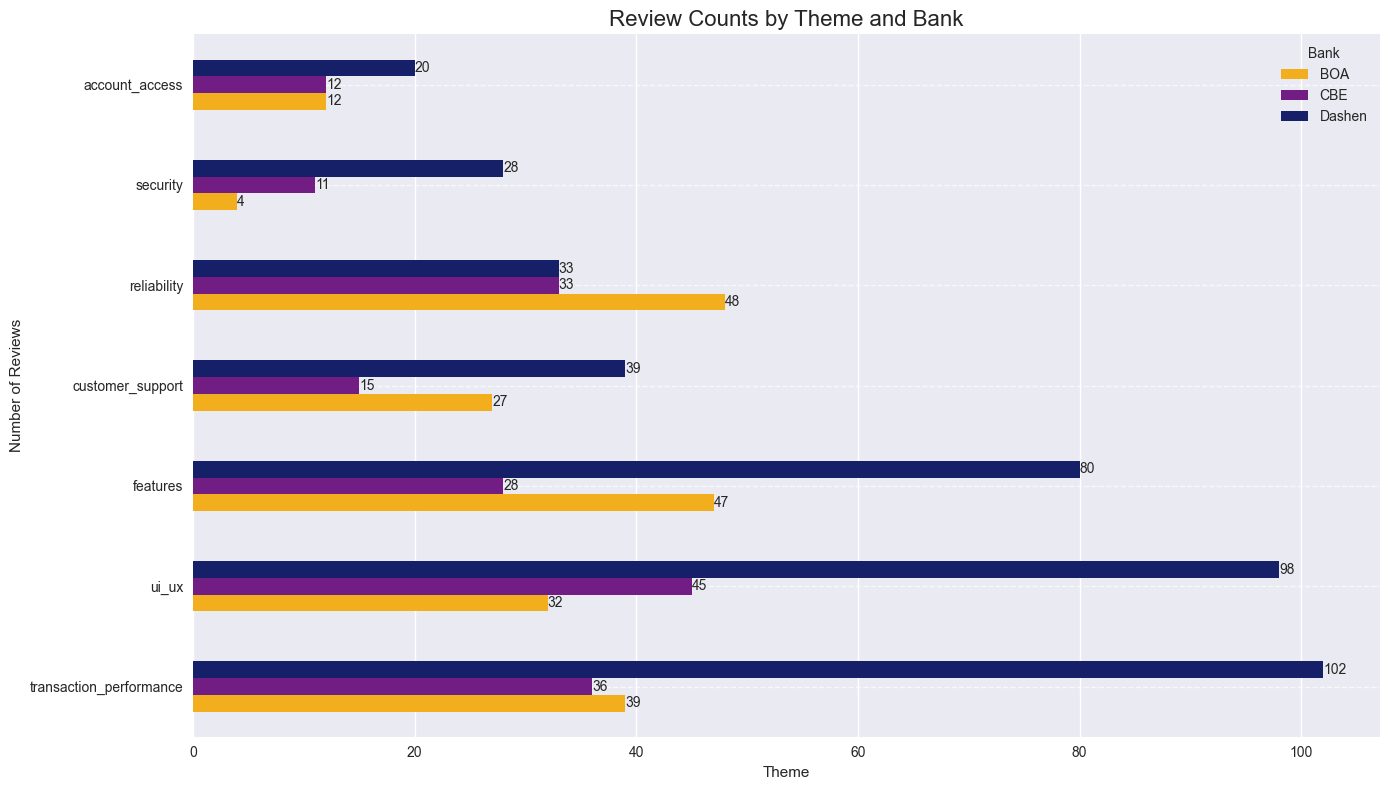

In [11]:
# Create a pivot table for theme counts by bank
theme_pivot = theme_df.pivot(index='theme', columns='bank', values='review_count')
theme_pivot = theme_pivot.fillna(0).sort_values(by='Dashen', ascending=False)

# Plot theme distribution
plt.figure(figsize=(14, 8))
ax = theme_pivot.plot(kind='barh', figsize=(14, 8), color=[bank_colors[bank] for bank in theme_pivot.columns])
plt.title('Review Counts by Theme and Bank', fontsize=16)
plt.xlabel('Theme')
plt.ylabel('Number of Reviews')
plt.legend(title='Bank')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10)
plt.tight_layout()
plt.show()


<Figure size 1400x800 with 0 Axes>

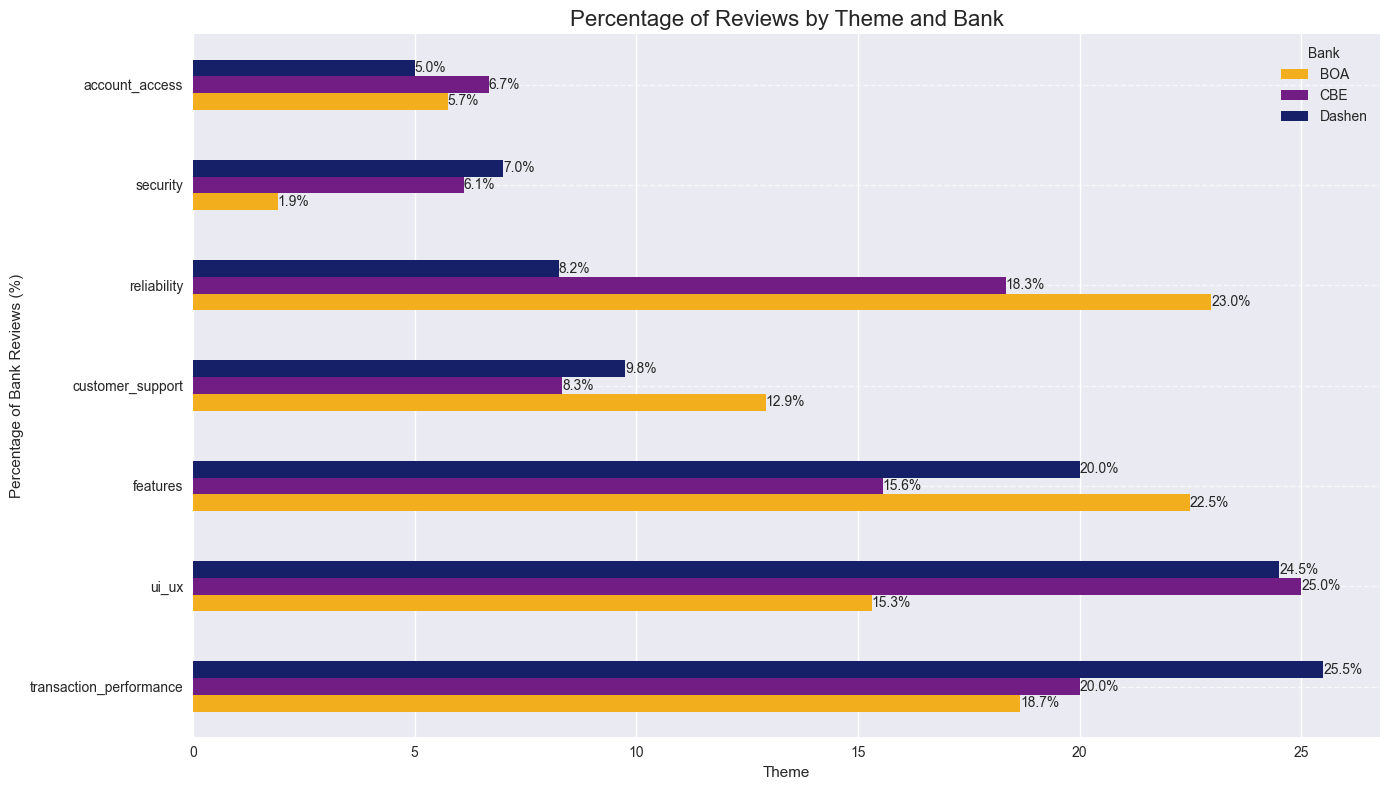

In [14]:
# Calculate percentage of reviews in each theme by bank
bank_totals = theme_df.groupby('bank')['review_count'].sum()
theme_df['theme_pct'] = theme_df.apply(lambda x: (x['review_count'] / bank_totals[x['bank']]) * 100, axis=1)

# Create pivot table for theme percentages
theme_pct_pivot = theme_df.pivot(index='theme', columns='bank', values='theme_pct')
theme_pct_pivot = theme_pct_pivot.fillna(0).sort_values(by='Dashen', ascending=False)

# Plot theme percentage distribution
plt.figure(figsize=(14, 8))
ax = theme_pct_pivot.plot(kind='barh', figsize=(14, 8), color=[bank_colors[bank] for bank in theme_pct_pivot.columns])
plt.title('Percentage of Reviews by Theme and Bank', fontsize=16)
plt.xlabel('Theme')
plt.ylabel('Percentage of Bank Reviews (%)')
plt.legend(title='Bank')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()


#### Sentiment Analysis by Theme

<Figure size 1400x800 with 0 Axes>

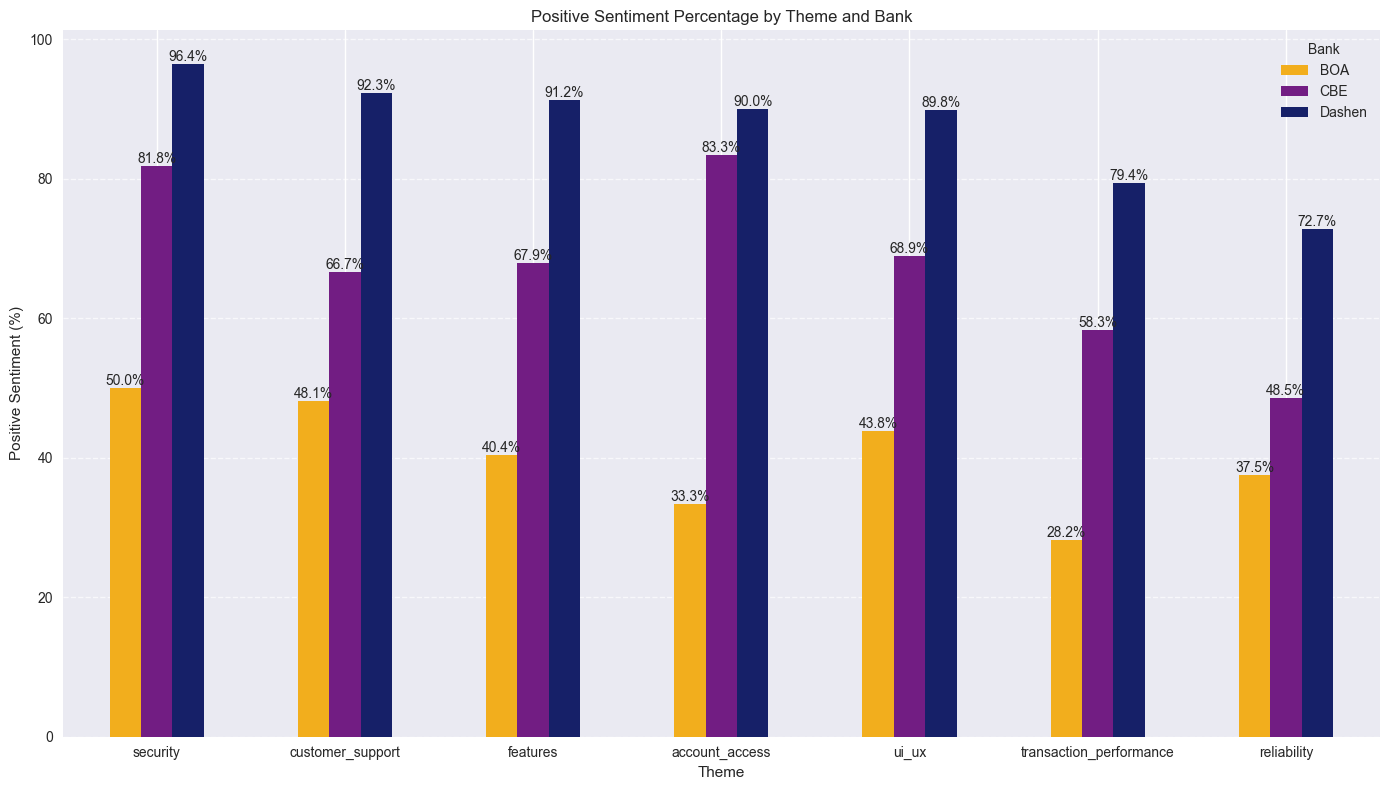

In [18]:
# Create pivot table for positive sentiment percentage by theme
positive_pivot = theme_df.pivot(index='theme', columns='bank', values='positive_pct')
positive_pivot = positive_pivot.fillna(0).sort_values(by='Dashen', ascending=False)

# Plot positive sentiment percentage
plt.figure(figsize=(14, 8))
ax = positive_pivot.plot(kind='bar', figsize=(14, 8), color=[bank_colors[bank] for bank in positive_pivot.columns])
plt.title('Positive Sentiment Percentage by Theme and Bank')
plt.xlabel('Theme')
plt.ylabel('Positive Sentiment (%)')
plt.legend(title='Bank')
plt.xticks(rotation=0, ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()


<Figure size 1400x800 with 0 Axes>

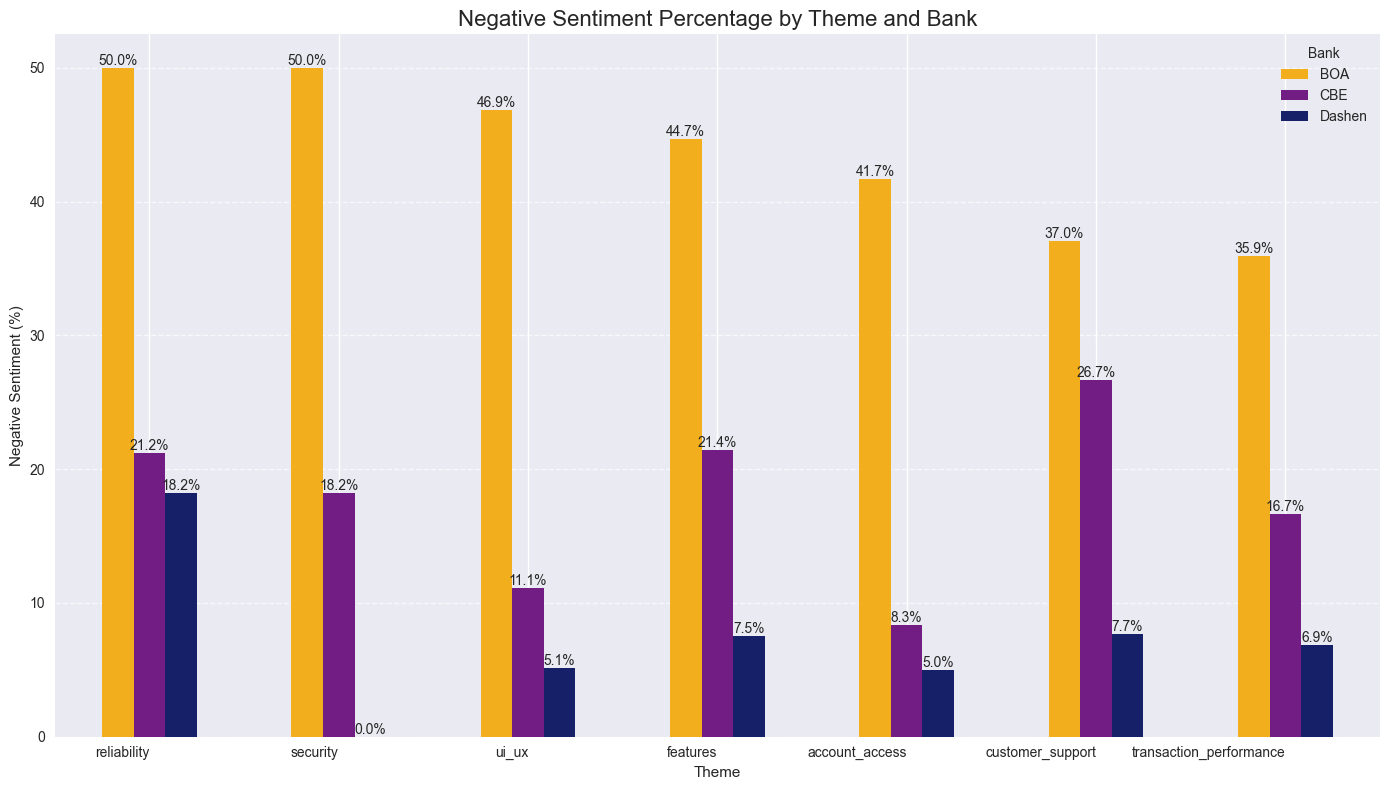

In [21]:
# Create pivot table for negative sentiment percentage by theme
negative_pivot = theme_df.pivot(index='theme', columns='bank', values='negative_pct')
negative_pivot = negative_pivot.fillna(0).sort_values(by='BOA', ascending=False)  # Sort by BOA as it has highest negative sentiment

# Plot negative sentiment percentage
plt.figure(figsize=(14, 8))
ax = negative_pivot.plot(kind='bar', figsize=(14, 8), color=[bank_colors[bank] for bank in negative_pivot.columns])
plt.title('Negative Sentiment Percentage by Theme and Bank', fontsize=16)
plt.xlabel('Theme')
plt.ylabel('Negative Sentiment (%)')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Bank')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()
